In [36]:
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler

# ---------------------------
# Cell Block 1: Configuration
# ---------------------------
PROJECT_ROOT = Path("..")
RAW_DATA_PATH = PROJECT_ROOT / "data" / "raw" / "dataset.csv"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
FEATURES_OUT_PATH = PROCESSED_DIR / "features.csv"
SCALER_OUT_PATH = PROCESSED_DIR / "scaler.pkl"

# We intentionally use these 8 numeric audio feature columns for similarity modeling.
FEATURE_COLS = [
    "acousticness",
    "danceability",
    "energy",
    "instrumentalness",
    "loudness",
    "speechiness",
    "tempo",
    "valence",
]

# Columns identified as not useful for our cosine similarity setup.
DROP_COLS = ["duration_ms", "explicit", "key", "mode", "liveness", "time_signature"]

# Keep these identifiers visible in downstream outputs for recommendation display.
KEY_METADATA_COLS = ["track_id", "track_name", "artists", "track_genre"]

EXPECTED_TOTAL_COLUMNS = 21

PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", 40)
print(f"Raw data path: {RAW_DATA_PATH}")
print(f"Processed dir: {PROCESSED_DIR}")

Raw data path: ..\data\raw\dataset.csv
Processed dir: ..\data\processed


In [37]:
# ------------------------------
# Cell Block 2: Load Raw Data
# ------------------------------
df_raw = pd.read_csv(RAW_DATA_PATH)

print("Shape:", df_raw.shape)
print("\nColumn count:", len(df_raw.columns))
print("\nColumns:")
print(df_raw.columns.tolist())
print("\nDtypes:")
display(df_raw.dtypes.to_frame("dtype").T)

if len(df_raw.columns) == EXPECTED_TOTAL_COLUMNS:
    print(f"\nColumn sanity check passed: found {EXPECTED_TOTAL_COLUMNS} columns.")
else:
    print(
        f"\nWarning: expected {EXPECTED_TOTAL_COLUMNS} columns but found {len(df_raw.columns)}."
    )

display(df_raw.head(3))

Shape: (114000, 21)

Column count: 21

Columns:
['Unnamed: 0', 'track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']

Dtypes:


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
dtype,int64,object,object,object,object,int64,int64,bool,float64,float64,int64,float64,int64,float64,float64,float64,float64,float64,float64,int64,object



Column sanity check passed: found 21 columns.


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.461,1,-6.746,0,0.1430,0.0322,0.000001,0.358,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.166,1,-17.235,1,0.0763,0.9240,0.000006,0.101,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.359,0,-9.734,1,0.0557,0.2100,0.000000,0.117,0.120,76.332,4,acoustic


# Data Notebook: Spotify Preprocessing Sandbox
This notebook explores, cleans, and scales the Spotify dataset before moving logic into production pipeline scripts.

Stages covered: configuration, load and sanity checks, EDA, cleaning, feature scaling, artifact saving, and validation.

## Cell Block 3 - Exploratory Data Analysis (EDA)
We examine nulls, duplicates, feature distributions, and correlations before cleaning.

In [38]:
# Null analysis
null_counts = df_raw.isnull().sum().sort_values(ascending=False)
null_counts = null_counts[null_counts > 0]

print("Columns with nulls:", len(null_counts))
display(null_counts.to_frame("null_count"))

# Duplicate analysis
dupe_by_track_id = df_raw.duplicated(subset=["track_id"]).sum() if "track_id" in df_raw.columns else None
full_row_dupes = df_raw.duplicated().sum()

print(f"Exact duplicate rows: {full_row_dupes}")
if dupe_by_track_id is not None:
    print(f"Duplicate track_id rows: {dupe_by_track_id}")
else:
    print("track_id column not found; cannot compute track-level duplicates.")

Columns with nulls: 3


,null_count
artists,1
track_name,1
album_name,1


Exact duplicate rows: 0
Duplicate track_id rows: 24259


,min,max,mean,std
acousticness,0.000,0.996,0.314910,0.332523
danceability,0.000,0.985,0.566800,0.173542
energy,0.000,1.000,0.641383,0.251529
instrumentalness,0.000,1.000,0.156050,0.309555
loudness,-49.531,4.532,-8.258960,5.029337
speechiness,0.000,0.965,0.084652,0.105732
tempo,0.000,243.372,122.147837,29.978197
valence,0.000,0.995,0.474068,0.259261


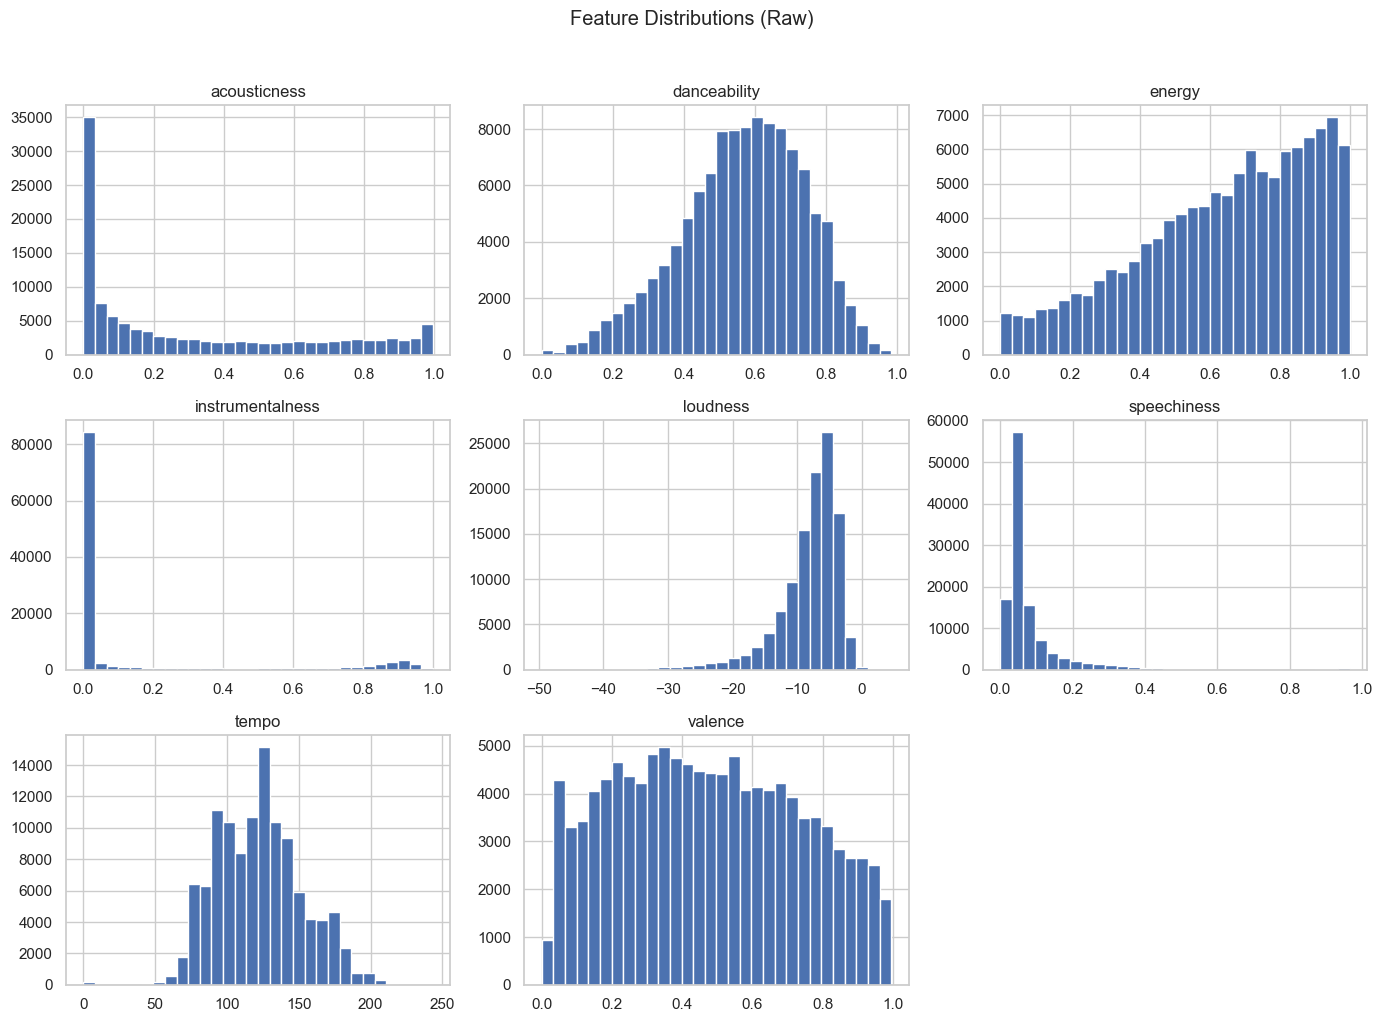

In [39]:
# Distribution analysis on the 8 selected features
feature_stats = df_raw[FEATURE_COLS].describe().T[["min", "max", "mean", "std"]]
display(feature_stats)

# Quick visual scan
axes = df_raw[FEATURE_COLS].hist(figsize=(14, 10), bins=30)
plt.suptitle("Feature Distributions (Raw)", y=1.02)
plt.tight_layout()
plt.show()

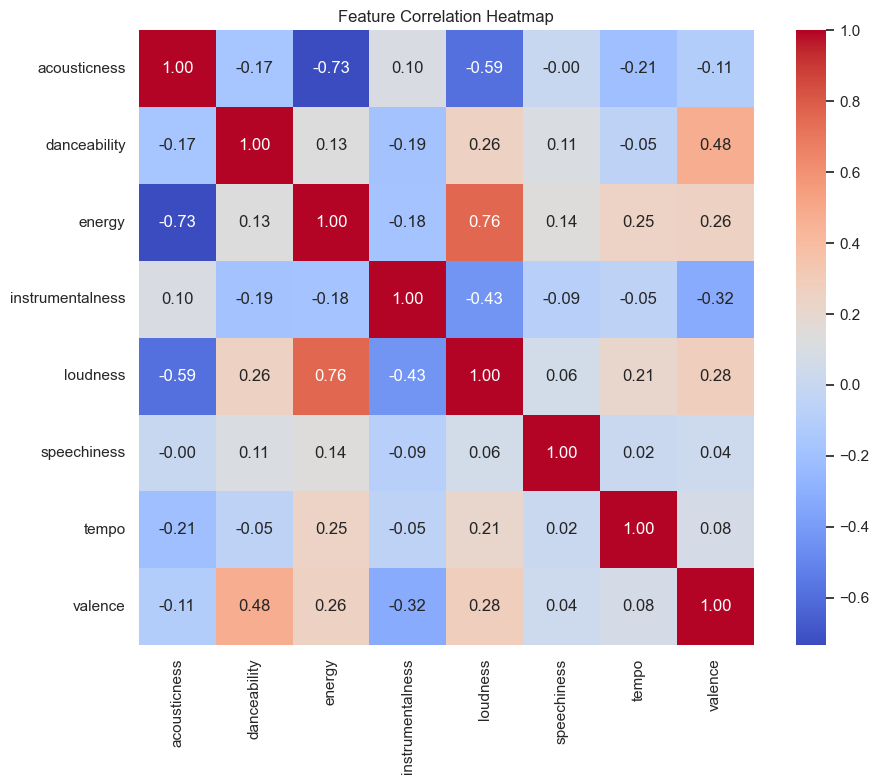

No feature pairs above correlation threshold 0.85.


In [40]:
# Correlation heatmap for selected features
corr = df_raw[FEATURE_COLS].corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", square=True)
plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

high_corr_pairs = []
for i, c1 in enumerate(FEATURE_COLS):
    for c2 in FEATURE_COLS[i + 1 :]:
        val = corr.loc[c1, c2]
        if abs(val) >= 0.85:
            high_corr_pairs.append((c1, c2, val))

if high_corr_pairs:
    print("Highly correlated feature pairs (|corr| >= 0.85):")
    for a, b, v in high_corr_pairs:
        print(f"- {a} vs {b}: {v:.3f}")
else:
    print("No feature pairs above correlation threshold 0.85.")

## Cell Block 4 - Cleaning
Drop predefined columns, remove nulls in feature columns, and deduplicate on track_id.

In [41]:
df_clean = df_raw.copy()

# Drop unused columns when present.
existing_drop_cols = [c for c in DROP_COLS if c in df_clean.columns]
df_clean = df_clean.drop(columns=existing_drop_cols)

before_null_drop = len(df_clean)
df_clean = df_clean.dropna(subset=FEATURE_COLS)
after_null_drop = len(df_clean)

if "track_id" in df_clean.columns:
    before_dedup = len(df_clean)
    df_clean = df_clean.drop_duplicates(subset=["track_id"], keep="first")
    after_dedup = len(df_clean)
else:
    before_dedup = after_dedup = len(df_clean)

print(f"Dropped columns: {existing_drop_cols}")
print(f"Rows before null drop: {before_null_drop:,}")
print(f"Rows after null drop:  {after_null_drop:,}")
print(f"Rows before dedup:     {before_dedup:,}")
print(f"Rows after dedup:      {after_dedup:,}")

display(df_clean.head(3))

Dropped columns: ['duration_ms', 'explicit', 'key', 'mode', 'liveness', 'time_signature']
Rows before null drop: 114,000
Rows after null drop:  114,000
Rows before dedup:     114,000
Rows after dedup:      89,741


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,0.676,0.461,-6.746,0.1430,0.0322,0.000001,0.715,87.917,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,0.420,0.166,-17.235,0.0763,0.9240,0.000006,0.267,77.489,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,0.438,0.359,-9.734,0.0557,0.2100,0.000000,0.120,76.332,acoustic


## Cell Block 5 - Feature Scaling
Fit StandardScaler on feature columns only and persist the scaler artifact.

In [42]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean[FEATURE_COLS])

df_processed = df_clean.copy()
df_processed.loc[:, FEATURE_COLS] = scaled_values

print("Scaled feature means (approx 0):")
display(df_processed[FEATURE_COLS].mean().round(4).to_frame("mean").T)
print("Scaled feature std (approx 1):")
display(df_processed[FEATURE_COLS].std().round(4).to_frame("std").T)

Scaled feature means (approx 0):


,acousticness,danceability,energy,instrumentalness,loudness,speechiness,tempo,valence
mean,-0.0,-0.0,0.0,-0.0,-0.0,0.0,-0.0,-0.0


Scaled feature std (approx 1):


,acousticness,danceability,energy,instrumentalness,loudness,speechiness,tempo,valence
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


## Cell Block 6 - Save Processed Output
Write cleaned+scaled features and scaler artifact to data/processed.

In [43]:
df_processed.to_csv(FEATURES_OUT_PATH, index=False)
joblib.dump(scaler, SCALER_OUT_PATH)

print(f"Saved features to: {FEATURES_OUT_PATH}")
print(f"Saved scaler to:   {SCALER_OUT_PATH}")

print("\nValidation checks:")
print("- Processed shape:", df_processed.shape)
print("- Feature columns present:", all(c in df_processed.columns for c in FEATURE_COLS))
print("- Key metadata columns present:", [c for c in KEY_METADATA_COLS if c in df_processed.columns])

display(df_processed.head(5))

Saved features to: ..\data\processed\features.csv
Saved scaler to:   ..\data\processed\scaler.pkl

Validation checks:
- Processed shape: (89741, 15)
- Feature columns present: True
- Key metadata columns present: ['track_id', 'track_name', 'artists', 'track_genre']


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,danceability,energy,loudness,speechiness,acousticness,instrumentalness,valence,tempo,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,0.644260,-0.675976,0.335731,0.490464,-0.875177,-0.535478,0.934036,-1.133609,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,-0.804604,-1.825609,-1.673094,-0.098361,1.760797,-0.535464,-0.770280,-1.479854,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,-0.702731,-1.073476,-0.236523,-0.280217,-0.349638,-0.535481,-1.329508,-1.518271,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,-1.676186,-2.240257,-1.918236,-0.451480,1.704637,-0.535263,-1.242010,1.981637,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,0.316001,-0.746123,-0.226373,-0.307584,0.415912,-0.535481,-1.150708,-0.070037,acoustic


In [44]:
df.shape

(114000, 21)

In [45]:
df_processed.shape

(89741, 15)

In [46]:
df_clean.shape

(89741, 15)